In [1]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

c:\Users\mijuu\Documents\mijuuhailu\fraud-transaction-detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
rf = joblib.load(
    "../models/fraud_random_forest.pkl"
)

In [3]:
test_df = pd.read_csv(
    "../data/processed/fraud_test_processed.csv"
)

X_test = test_df.drop("class", axis=1)
y_test = test_df["class"]

In [4]:
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
6,device_transaction_count,0.338927
2,time_since_signup,0.242840
4,day_of_week,0.083628
3,hour_of_day,0.070218
1,age,0.069009
0,purchase_value,0.066003
178,country_United States,0.011815
8,source_SEO,0.007056
10,browser_IE,0.006121
7,source_Direct,0.006040


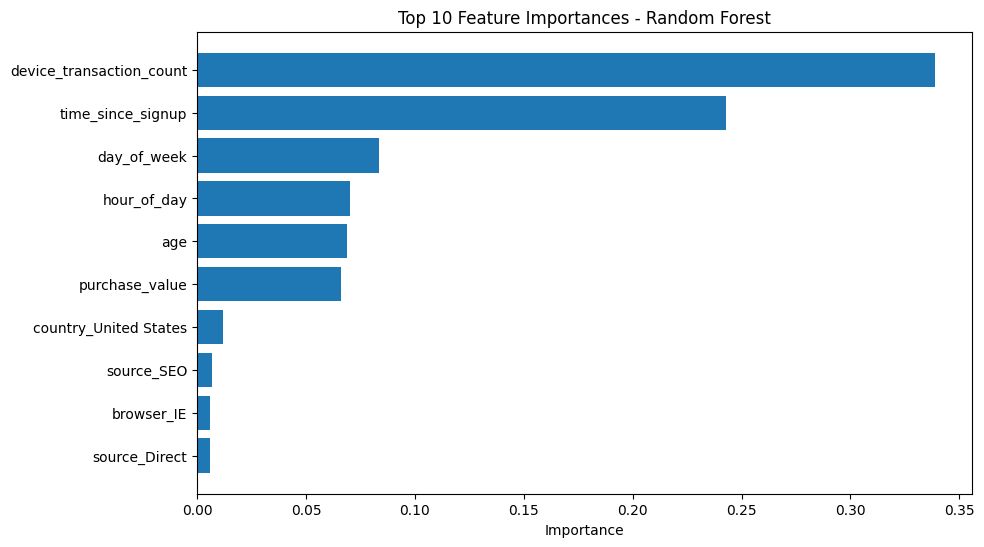

In [5]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 10 Feature Importances - Random Forest"
)

plt.xlabel("Importance")

plt.show()

In [6]:
feature_importance.head(10)

,Feature,Importance
6,device_transaction_count,0.338927
2,time_since_signup,0.242840
4,day_of_week,0.083628
3,hour_of_day,0.070218
1,age,0.069009
0,purchase_value,0.066003
178,country_United States,0.011815
8,source_SEO,0.007056
10,browser_IE,0.006121
7,source_Direct,0.006040


In [ ]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    max_display=10
)